In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix  
import pathlib
import PIL
import cv2

from tensorflow.keras import models, layers 

'''
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
'''

I0000 00:00:1780116178.852703   37302 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780116178.853154   37302 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780116178.894347   37302 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780116179.994326   37302 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

'\nfrom tensorflow.keras.models import Sequential\nfrom tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D\n'

In [3]:
# 1. feed-forward NN - Multiclass Image Classification on MNIST 

(x_train, y_train), (x_test, y_test) = mnist.load_data()
#plt.matshow(x_train[1]), x_train.shape --> (60000, 28, 28)

'''
norm_layer = layers.Normalization()
norm_layer.adapt(x_train)
'''
model = models.Sequential([
    layers.Input(shape=(28,28)), #ghost layer to map inputs, created by arg input_shape=(28, 28) of first layer automatically
    layers.Rescaling(1./255),
    layers.Flatten(),
    layers.Dense(units=128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(units=10, activation="softmax") #10 classes
])

# sparse_categorical_crossentropy loss since y_target variables are integers 
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.fit(x_train, y_train, epochs=2, batch_size=32)
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\n\ntest_loss : {test_loss}, test_accuracy : {test_acc}")
model.summary() # None --> bach size, each row for each sample 

Epoch 1/2


E0000 00:00:1780109514.611139   32133 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9139 - loss: 0.2967
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9571 - loss: 0.1435
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9705 - loss: 0.1007


test_loss : 0.10065779834985733, test_accuracy : 0.9704999923706055


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

In [35]:
y_pred_0 = np.argmax(model.predict(x_test[0:1])) # max probability arg/label # shape --> (1, 28,28), x_test[0] --> (28,28)
y_test_0 = y_test[0]
print(y_pred_0, y_test_0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
7 7


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[7 2 1 ... 4 5 6]
[7 2 1 ... 4 5 6]


<Axes: >

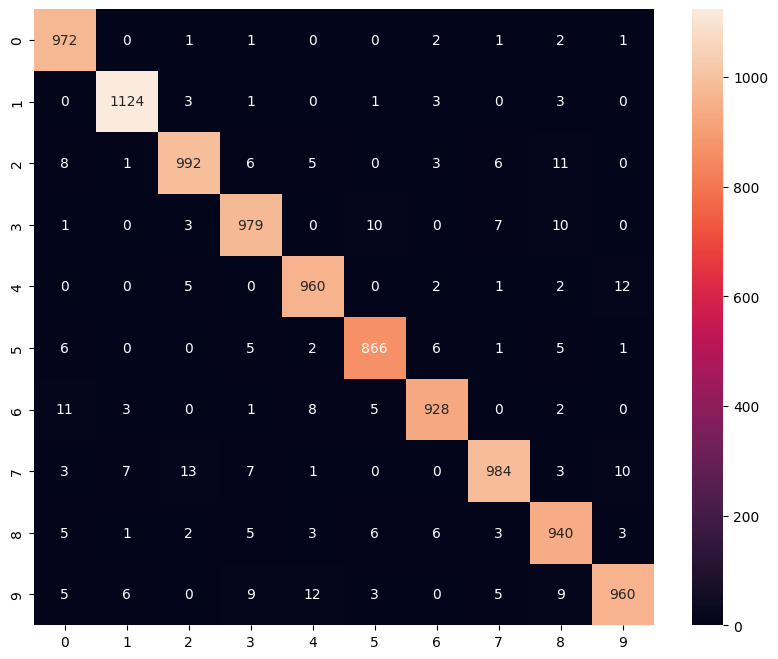

In [20]:
#y_pred = [np.argmax(i).item() for i in model.predict(x_test)]
y_pred = np.argmax(model.predict(x_test), axis=1)
print(y_pred)
print(y_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')

In [47]:
# 2, CNN - Multiclass Image Classification on CIFAR10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, y_train = x_train[:10000], y_train[:10000]
x_test, y_test = x_test[:2000], y_test[:2000]
y_test[0]

array([3], dtype=uint8)

In [48]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)
y_test[0] # to demonstrate using catgorical cross entopy loss for one hot encoded y target

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [53]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(32,32,3)), #batch will be another dimension while training
    layers.Conv2D(filters=32, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(1,1), padding='same'), # same --> paddding=1 so output dim are same, valid --> padding=0
    layers.Flatten(),
    layers.Dense(units=128, activation="relu"),
    layers.Dense(units=10, activation="softmax")
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=2, batch_size=64, validation_data=(x_test, y_test))
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\n\ntest_loss : {test_loss}, test_accuracy : {test_acc}")
model.summary()

Epoch 1/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.2507 - loss: 2.2007 - val_accuracy: 0.3580 - val_loss: 1.7555
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.4197 - loss: 1.5961 - val_accuracy: 0.4540 - val_loss: 1.5311
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4540 - loss: 1.5311


test_loss : 1.5310817956924438, test_accuracy : 0.45399999618530273


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,589,856 (48.03 MB)

 Trainable params: 4,196,618 (16.01 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,393,238 (32.02 MB)

In [62]:
cifar10_classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

# Example usage with class index 3
print(cifar10_classes[np.argmax(model.predict(x_test[0:1]))])
print(cifar10_classes[int(y_test[0][0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
cat
airplane


In [22]:
# 3. classiification of flowers and data augmentation = CNN & Transfer Learning using pre-trained models

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
archive = tf.keras.utils.get_file(fname="flowers", origin=dataset_url, untar=True)
data_dir = pathlib.Path(archive) / "flower_photos"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,  
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32,
)

class_names = train_ds.class_names 

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

data_augmentation = models.Sequential([
        layers.RandomFlip("horizontal", input_shape=(180, 180, 3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
])

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [23]:
#CNN model

model = models.Sequential([
        data_augmentation,
        layers.Rescaling(1.0 / 255),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(len(class_names)),
])

# loss="sparse_categorical_crossentropy" expects probabilities from softmax, Relu returns logits 
model.compile(optimizer="adam", loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])
model.fit(train_ds, validation_data=test_ds, epochs=5)
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\n\ntest_loss : {test_loss}, test_accuracy : {test_accuracy}")
model.summary()

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 202ms/step - accuracy: 0.3849 - loss: 1.4376 - val_accuracy: 0.5150 - val_loss: 1.2100
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.5433 - loss: 1.1128 - val_accuracy: 0.5668 - val_loss: 1.0864
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 220ms/step - accuracy: 0.5862 - loss: 1.0337 - val_accuracy: 0.6144 - val_loss: 1.0033
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 217ms/step - accuracy: 0.6356 - loss: 0.9306 - val_accuracy: 0.5995 - val_loss: 1.0775
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.6666 - loss: 0.8773 - val_accuracy: 0.6526 - val_loss: 0.9061
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.6526 - loss: 0.9061


test_loss : 0.9061342477798462, test_accuracy : 0.6525885462760925


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,967,857 (45.65 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,978,572 (30.44 MB)

In [21]:
test_iterator = iter(test_ds)
x_batch, y_batch = next(test_iterator)

x_test_0 = x_batch[0:1]  # Shape is (1, 180, 180, 3)
y_test_0 = class_names[y_batch[0].numpy()]  
y_pred_0 = class_names[np.argmax(model.predict(x_test_0))]
print(y_test_0, y_pred_0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
dandelion daisy


In [24]:
# Transfer Learning using Mobile_Net pre-trained model instead of CNN

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,  # Exclude the final classification layer
    weights="imagenet",  # Load weights trained on ImageNet datset
)

# Freeze the base model so its pre-trained weights don't change during training
base_model.trainable = False

model = models.Sequential([
        data_augmentation,
        layers.Lambda(preprocess_input),  # Preprocesses pixels specifically for MobileNet
        base_model,  # Outputs 3D feature maps
        layers.GlobalAveragePooling2D(),  # Converts 3D features to a 1D feature vector (Instead of Flatten(), reduce overfitting)
        layers.Dropout(0.2),  # Regularization
        layers.Dense(len(class_names)),  # Final classification layer (Outputs logits)
])

model.compile(optimizer="adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])
model.summary()

# Train the Top Layers
model.fit(train_ds, validation_data=test_ds, epochs=5) #converges quickly
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\n\ntest_loss : {test_loss}, test_accuracy : {test_accuracy}")
model.summary()

/tmp/ipykernel_37302/2387013320.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,201 (8.69 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 12,812 (50.05 KB)

In [27]:
# Image Similarity using Resnet50 model
preprocess_input = tf.keras.applications.resnet50.preprocess_input

resnet_base = tf.keras.applications.ResNet50(
    input_shape=(180, 180, 3), include_top=False, weights="imagenet"
)

# Create a clean feature extraction pipeline
feature_extractor = tf.keras.Sequential([
        layers.Lambda(preprocess_input),  # Scales pixels to ResNet expectations
        resnet_base,
        layers.GlobalAveragePooling2D(),  # Flattens the 3D features to a 1D vector
]) # doesnt needed to be compiled/fitted since isnt adding new layers for training a new model

# Pull two separate images using slicing
iterator = iter(test_ds)
x_batch, y_batch = next(iterator)
img_A = x_batch[0:1]
img_B = x_batch[1:2] #4D

flower_name_A = class_names[y_batch[0].numpy()]
flower_name_B = class_names[y_batch[1].numpy()]

# Extract their feature vectors
# .predict() returns an array of shape (1, 2048)
vector_A = feature_extractor.predict(img_A)[0]
vector_B = feature_extractor.predict(img_B)[0]

print("\n--- Feature Vector Info ---")
print(f"Vector A shape: {vector_A.shape} | Ground Truth: {flower_name_A}")
print(f"Vector B shape: {vector_B.shape} | Ground Truth: {flower_name_B}")

# Calculate Cosine Similarity
cosine_loss_fn = tf.keras.losses.CosineSimilarity()
raw_loss = cosine_loss_fn(vector_A, vector_B).numpy() # Calculate the loss (outputs a negative number for high similarity)
similarity = -1 * raw_loss # Convert the loss back to a standard similarity score (scale: -1.0 to 1.0)

print("\n--- Comparison Result ---")
print(f"Cosine Similarity Score: {similarity:.4f}")

print("\n--- Comparison Result using Built-in Fn ---")
print(f"Cosine Similarity Score: {similarity:.4f}")

if similarity > 0.8:
    print("Result: The two images are highly visually similar!")
else:
    print("Result: The two images have distinct visual features.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 948ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step

--- Feature Vector Info ---
Vector A shape: (2048,) | Ground Truth: dandelion
Vector B shape: (2048,) | Ground Truth: daisy

--- Comparison Result ---
Cosine Similarity Score: 0.3901

--- Comparison Result using Built-in Fn ---
Cosine Similarity Score: 0.3901
Result: The two images have distinct visual features.


In [34]:
# Image Preprocessing for TensorFlow ResNet ---
IMG_SIZE = (224, 224) # ResNet50 expects 224x224 input

def load_and_preprocess_image_tf(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
    img_array = preprocess_input(img_array) # ResNet specific preprocessing
    return img_array

# --- 2. Initialize ResNet50 for Feature Extraction (Comparison) ---
# We remove the top (classification) layer to get feature vectors
feature_extractor = ResNet50(weights='imagenet', include_top=False, pooling='avg')

# --- 3. Initialize ResNet50 for Classification ---
# This model includes the classification layer
classifier = ResNet50(weights='imagenet')

# --- 4. Load your real images ---
# Adjust these paths to your actual image locations in Google Drive
img_path1 = "./public/cat1.webp"
img_path2 = "./public/bottle.jpg"

# Ensure images exist
if not os.path.exists(img_path1) or not os.path.exists(img_path2):
    print("Error: One or both image paths are incorrect. Please check your paths.")
else:
    img_tensor1 = load_and_preprocess_image_tf(img_path1)
    img_tensor2 = load_and_preprocess_image_tf(img_path2)

    # --- 5. Extract Features for Comparison ---
    features1 = feature_extractor.predict(img_tensor1, verbose=0)
    features2 = feature_extractor.predict(img_tensor2, verbose=0)

    # --- 6. Calculate Similarity Score (Cosine Similarity) ---
    # Cosine similarity is 1 - cosine distance
    similarity_score = 1 - cosine(features1.flatten(), features2.flatten())
    print("\n--- Image Comparison Results (TensorFlow) ---")
    print(f"Similarity Score between the two images: {similarity_score:.4f}")

    # --- 7. Classify Images ---
    print("\n--- Image Classification Results (TensorFlow) ---")

    # Predict for image 1
    predictions1 = classifier.predict(img_tensor1, verbose=0)
    # Decode the predictions to get human-readable labels
    decoded_predictions1 = decode_predictions(predictions1, top=3)[0]
    print(f"Image 1 Classification:")
    for i, (imagenet_id, label, score) in enumerate(decoded_predictions1):
        print(f"  {i+1}: {label} ({score:.2f})")

    # Predict for image 2
    predictions2 = classifier.predict(img_tensor2, verbose=0)
    decoded_predictions2 = decode_predictions(predictions2, top=3)[0]
    print(f"\nImage 2 Classification:")
    for i, (imagenet_id, label, score) in enumerate(decoded_predictions2):
        print(f"  {i+1}: {label} ({score:.2f})")



--- Image Comparison Results (TensorFlow) ---
Similarity Score between the two images: 0.2172

--- Image Classification Results (TensorFlow) ---


Image 1 Classification:
  1: tiger_cat (0.35)
  2: tabby (0.14)
  3: Egyptian_cat (0.13)

Image 2 Classification:
  1: lighter (0.93)
  2: water_bottle (0.07)
  3: water_jug (0.00)


In [ ]:
# 4. Object Detection : Object Classification + Localisation using bounding boxes
# Image Segmentation:  Pixel Classification  

/home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


Model loaded successfully!
Detected dog (92.6%) at [50, 26, 251, 187]
Detected cat (91.7%) at [42, 45, 168, 188]
Detected Object ID: 65 (51.8%) at [25, 22, 253, 181]


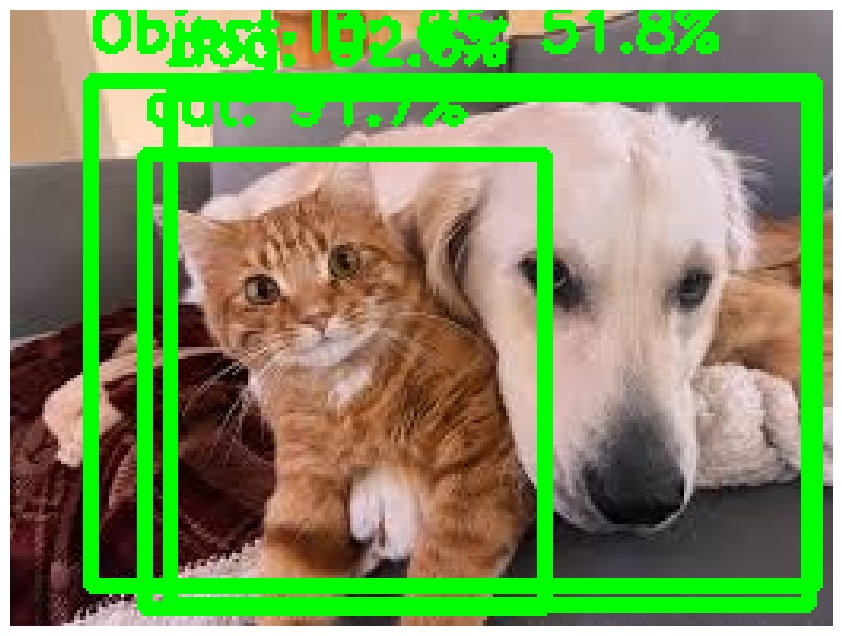

In [32]:
# 1. Load the pre-trained Faster R-CNN model from TensorFlow Hub
# use ResNet50 V1 as the backbone network for feature extraction
model_url = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
detector = hub.load(model_url)
print("Model loaded successfully!")

# 2. Load and preprocess your test image
image_path = "./public/dogncat.jpeg" 
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# TensorFlow Hub object detection models expect a 4D uint8 tensor: [batch_size, height, width, 3]
input_tensor = tf.convert_to_tensor(img_rgb)
input_tensor = input_tensor[tf.newaxis, ...]  # Use slicing to add the 4D batch dimension

# 3. Run Object Detection (Inference)
detector_output = detector(input_tensor)

# 4. Parse the output dictionaries
# TF Hub returns normalized coordinates [ymin, xmin, ymax, xmax] scaled between 0 and 1
boxes = detector_output["detection_boxes"][0].numpy()
class_ids = detector_output["detection_classes"][0].numpy().astype(int)
scores = detector_output["detection_scores"][0].numpy()

# 5. Draw the results on the image
output_img = img_rgb.copy()
h, w, _ = output_img.shape
CONFIDENCE_THRESHOLD = 0.50

# Note: COCO labels map to integers. Here is a baseline mapping for common classes:
# (For a full 90-class list, you can download the mscoco_label_map)
COCO_LABELS = {
    1: "person",
    2: "bicycle",
    3: "car",
    4: "motorcycle",
    6: "bus",
    8: "truck",
    17: "cat",
    18: "dog",
    19: "horse",
}

for i in range(len(scores)):
    score = scores[i]
    if score > CONFIDENCE_THRESHOLD:
        # Denormalize the bounding box coordinates back to original pixel dimensions
        ymin, xmin, ymax, xmax = boxes[i]
        x1, y1 = int(xmin * w), int(ymin * h)
        x2, y2 = int(xmax * w), int(ymax * h)

        # Look up the string label name
        class_id = class_ids[i]
        label_name = COCO_LABELS.get(class_id, f"Object ID: {class_id}")

        # Draw the box rectangle
        cv2.rectangle(output_img, (x1, y1), (x2, y2), (0, 255, 0), 3)

        # Draw the label text above the bounding box
        text = f"{label_name}: {score*100:.1f}%"
        cv2.putText(
            output_img,
            text,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
        )

        print(f"Detected {label_name} ({score*100:.1f}%) at [{x1}, {y1}, {x2}, {y2}]")

# Display final rendered visual
plt.figure(figsize=(12, 8))
plt.imshow(output_img)
plt.axis("off")
plt.show()

Loading pre-trained YOLOv8 model...
Model loaded successfully!
Running object detection...

0: 480x640 1 cat, 2 dogs, 2 beds, 49.7ms
Speed: 1.3ms preprocess, 49.7ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

--- Detection Results ---
Detected cat (50.1%) at [42, 58, 165, 192]
Detected bed (35.3%) at [0, 5, 256, 192]
Detected dog (27.9%) at [122, 27, 241, 167]
Detected dog (27.5%) at [18, 27, 252, 188]
Detected bed (27.0%) at [0, 91, 244, 193]


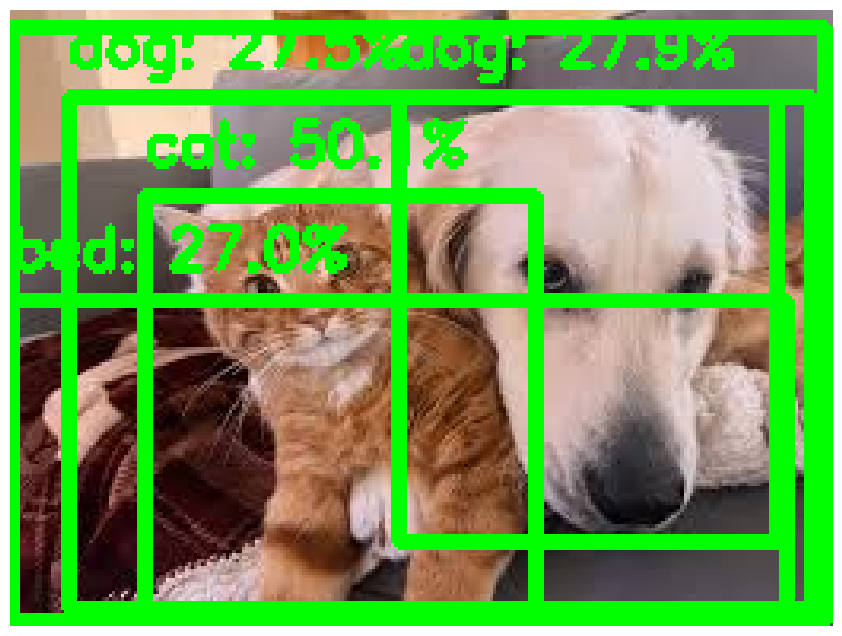

In [6]:
# 1. Load a Pre-trained YOLO model
# "yolov8n.pt" is the Nano version (blazing fast, lightweight) pre-trained on COCO (80 classes)
print("Loading pre-trained YOLOv8 model...")
model = YOLO("yolov8n.pt")
print("Model loaded successfully!")

# 2. Load your test image
image_path = "./public/dogncat.jpeg" 
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 3. Run Object Detection (Inference)
# YOLO natively handles preprocessing, scaling, and Non-Max Suppression (NMS) internally!
print("Running object detection...")
results = model(img_rgb, conf=0.25)  # Setting confidence threshold to 25%

# 4. Parse and draw results
# Ultralytics provides a structured 'Results' object containing all prediction metrics
output_img = img_rgb.copy()
result = results[0]  # Get results for our single input image

# Extract boxes details safely
boxes = result.boxes.xyxy.cpu().numpy()  # Extracted coordinates as [x1, y1, x2, y2]
scores = result.boxes.conf.cpu().numpy()  # Confidence scores
class_ids = result.boxes.cls.cpu().numpy().astype(int)  # Class integer IDs
class_names = result.names  # Dictionary mapping integer IDs to string names

print("\n--- Detection Results ---")
for i in range(len(scores)):
    x1, y1, x2, y2 = map(int, boxes[i])
    score = scores[i]
    label_name = class_names[class_ids[i]]

    # Draw the box rectangle
    cv2.rectangle(output_img, (x1, y1), (x2, y2), (0, 255, 0), 3)

    # Draw the label text above the bounding box
    text = f"{label_name}: {score*100:.1f}%"
    cv2.putText(
        output_img,
        text,
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2,
    )

    print(f"Detected {label_name} ({score*100:.1f}%) at [{x1}, {y1}, {x2}, {y2}]")

# Display final rendered visual
plt.figure(figsize=(12, 8))
plt.imshow(output_img)
plt.axis("off")
plt.show()

In [10]:
def main():
    # 1. Initialize the YOLO model
    # 'yolov8n.pt' is ultra-lightweight and perfect for real-time webcam frame rates
    model = YOLO("yolov8n.pt")
    
    # 2. Open the real-time camera stream
    # 0 is usually the built-in webcam. Change to 1 or 2 if using an external USB camera.
    '''
    camera_index = 0
    cap = cv2.VideoCapture(camera_index)
    '''
    video_path = "./public/od_vid.mp4" 
    cap = cv2.VideoCapture(video_path)

    '''
    if not cap.isOpened():
        print(f"Error: Could not open camera source index {camera_index}")
        return

    print("Real-time camera initialized successfully.")
    print("-> Press 'q' on your keyboard while focusing the video window to exit.")
    '''
    
    # 3. Process the live stream frame-by-frame
    while True:
        # Capture frame-by-frame from the camera
        success, frame = cap.read()
        
        if not success:
            print("Error: Failed to grab frame from camera.")
            break

        # Run YOLO inference on the raw OpenCV frame
        # stream=True optimizes memory usage for continuous video feeds
        results = model(frame, conf=0.35, iou=0.45)

        # Iterate through results (since stream=True returns a generator)
        for r in results:
            # Draw standard YOLO bounding boxes, labels, and confidences on the frame
            annotated_frame = r.plot()
            
            # (Optional) Add a custom text overlay, like a frame title
            cv2.putText(
                annotated_frame, 
                "YOLO Live Camera Feed", 
                (20, 40), 
                cv2.FONT_HERSHEY_SIMPLEX, 
                1, 
                (0, 255, 0), 
                2
            )

            # Display the resulting frame in a custom window
            cv2.imshow("Object Detection", annotated_frame)

        # 4. Handle Exit Condition
        # Wait 1 millisecond for a keystroke. If 'q' is pressed, break the loop.
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("Exiting live stream...")
            break

    # 5. Clean up camera hardware and close open windows properly
    cap.release()
    cv2.destroyAllWindows()
    print("Camera released and windows closed clean.")

if __name__ == "__main__":
    main()


0: 384x640 1 person, 4 cars, 1 bus, 42.2ms
Speed: 1.5ms preprocess, 42.2ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 4 cars, 1 bus, 47.9ms
Speed: 1.6ms preprocess, 47.9ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 1 bus, 43.7ms
Speed: 1.7ms preprocess, 43.7ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 4 cars, 1 bus, 37.5ms
Speed: 1.7ms preprocess, 37.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 4 cars, 1 bus, 34.3ms
Speed: 1.5ms preprocess, 34.3ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 4 cars, 1 bus, 33.6ms
Speed: 3.4ms preprocess, 33.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 4 cars, 1 bus, 42.3ms
Speed: 2.4ms preprocess, 42.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 4

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

# =====================================================================
# 1. DEFINE THE MINIMAL VISION TRANSFORMER CLASS
# =====================================================================
class MinimalViT(models.Model):
    def __init__(self, patch_size=4, num_classes=10, embed_dim=64, num_heads=4):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        # LAYER 1: SCALE PIXELS
        self.rescale = layers.Rescaling(1.0 / 255.0)

        # LAYER 2 & 3: PATCH EMBEDDER & FLATTENER
        # Slices the image into non-overlapping blocks and projects them
        self.patch_conv = layers.Conv2D(filters=embed_dim, kernel_size=patch_size, strides=patch_size)
        self.flatten_sequence = layers.Reshape(target_shape=(-1, embed_dim))

        # LAYER 4: MULTI-HEAD SELF-ATTENTION (Built-in)
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)

        # LAYER 5: FEED-FORWARD NETWORK (MLP)
        self.mlp = models.Sequential([
            layers.Dense(embed_dim * 2, activation=tf.nn.gelu),
            layers.Dense(embed_dim),
        ])

        # LAYER 6: LAYER NORMALIZATIONS
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)

        # LAYER 7 & 8: POOLING & CLASSIFIER HEAD
        self.global_pool = layers.GlobalAveragePooling1D()
        self.classifier = layers.Dense(num_classes)

    def build(self, input_shape):
        # LAYER 9: LEARNABLE POSITION EMBEDDING
        # Auto-calculates patch count: (32 // 4) * (32 // 4) = 64 patches
        num_patches = (input_shape[1] // self.patch_size) * (input_shape[2] // self.patch_size)
        self.pos_embedding = self.add_weight(
            name="pos_embed",
            shape=(1, num_patches, self.embed_dim),
            initializer="random_normal",
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        x = self.rescale(inputs)
        x = self.patch_conv(x)
        x = self.flatten_sequence(x)
        x = x + self.pos_embedding

        # Room 1: Attention + Skip Connection
        norm_x1 = self.norm1(x)
        attn_out = self.attention(query=norm_x1, value=norm_x1, key=norm_x1)
        x2 = layers.Add()([attn_out, x])

        # Room 2: MLP Processing + Skip Connection
        norm_x2 = self.norm2(x2)
        mlp_out = self.mlp(norm_x2)
        x3 = layers.Add()([mlp_out, x2])

        pooled = self.global_pool(x3)
        logits = self.classifier(pooled)
        return logits


# =====================================================================
# 2. LOAD AND PREPARE DATASET (CIFAR-10)
# =====================================================================
print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")


# =====================================================================
# 3. INITIALIZE, COMPILE, AND FIT THE MODEL
# =====================================================================
# Instantiate our unified single-class model
model = MinimalViT(patch_size=4, num_classes=10, embed_dim=64, num_heads=4)

# COMPILING: Connect loss math, optimization strategy, and metrics
# Transformers benefit immensely from AdamW (weight decay protects against overfitting)
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# FITTING: Kick off the actual training iterations
# Running 5 epochs for a quick verification test. Increase epochs for real convergence.
print("\n--- Starting Training Loop ---")
history = model.fit(
    x_train, 
    y_train, 
    batch_size=128, 
    epochs=5, 
    validation_split=0.1
)


# =====================================================================
# 4. EVALUATE ON TEST DATA
# =====================================================================
print("\n--- Evaluating on Unseen Test Dataset ---")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f"\nFinal Test Accuracy: {test_acc * 100:.2f}%")

Task was destroyed but it is pending!
task: <Task pending name='Task-132' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-133' coro=<Kernel.shell_main() running at /home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/usr/lib/python3.13/collections/__init__.py:450: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  @classmethod
Task was destroyed but it is pending!
task: <Task pending name='Task-133' coro=<Kernel.shell_main() running at /home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


Loading CIFAR-10 dataset...
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)

--- Starting Training Loop ---
Epoch 1/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 24s 61ms/step - accuracy: 0.3168 - loss: 1.8253 - val_accuracy: 0.3728 - val_loss: 1.6743
Epoch 2/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.4393 - loss: 1.5308 - val_accuracy: 0.4436 - val_loss: 1.4965
Epoch 3/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.4799 - loss: 1.4293 - val_accuracy: 0.5018 - val_loss: 1.3720
Epoch 4/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.5055 - loss: 1.3649 - val_accuracy: 0.5140 - val_loss: 1.3439
Epoch 5/5
352/352 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.5271 - loss: 1.3091 - val_accuracy: 0.5256 - val_loss: 1.2999

--- Evaluating on Unseen Test Dataset ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5267 - loss: 1.3076

Final Test Accuracy: 52.67%


In [28]:
import os

# FORCE RE-ROUTING: Tell Keras to use PyTorch as the engine.
# This completely dodges the legacy TensorFlow C++ errors on Python 3.13!
os.environ["KERAS_BACKEND"] = "torch"

import keras
import keras_hub
from keras import layers

# =====================================================================
# 1. LOAD DATASET (CIFAR-10 via Keras)
# =====================================================================
print("Loading CIFAR-10 dataset...")
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# =====================================================================
# 2. CREATE A CLEAN SEQUENTIAL PIPELINE (ResNet Style)
# =====================================================================

# Load the pre-trained ImageNet backbone from KerasHub
vit_base = keras_hub.models.ViTBackbone.from_preset("vit_base_patch16_224_imagenet")

# Freeze the backbone weights so we only train our final layer
vit_base.trainable = False

# Build the layout exactly like your ResNet50 workflow
model = keras.Sequential(
    [
        layers.Input(shape=(32, 32, 3)),  # Raw image input
        layers.Resizing(224, 224),        # ViT preset expects 224x224 inputs
        layers.Rescaling(1.0 / 255.0),    # Normalize pixels to [0, 1]
        
        vit_base,                         # The pre-trained frozen ViT layer
        
        # ViT backbones output sequence tokens. We average pool them over the 
        # sequence dimension to get a clean 1D feature vector.
        layers.GlobalAveragePooling1D(),  
        
        layers.Dense(10),                 # Final custom 10-class output layer
    ]
)

# =====================================================================
# 3. COMPILE AND FIT
# =====================================================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

print("\n--- Model Architecture ---")
model.summary()

print("\n--- Starting Training Loop ---")
# Training on a 1000-image slice for a quick verification run
model.fit(
    x_train[:1000], y_train[:1000], batch_size=32, epochs=3, validation_split=0.1
)

NotFoundError: /home/aaron/Documents/ml-dl/venv/lib/python3.13/site-packages/tensorflow_text/python/ops/_regex_split_ops.so: undefined symbol: _ZN10tensorflow12OpDefBuilder10SetShapeFnESt8functionIFN4absl12lts_202501276StatusEPNS_15shape_inference16InferenceContextEEE